# Modelado de la volatilidad implícita de opciones con regresión

**Proyecto final — Análisis de Regresión**

**Integrantes:** [Nombres del equipo]

En este trabajo buscamos explicar la volatilidad implícita de opciones usando diferentes modelos de regresión y comparar cuál funciona mejor.

## 1. Objetivos

### Objetivo general

Construir y comparar modelos de regresión que permitan explicar la volatilidad implícita de opciones a partir de características del contrato y del mercado.

### Objetivos específicos

- Limpiar y transformar el dataset para poder usarlo en modelos de regresión.
- Ajustar tres modelos distintos.
- Comparar cada modelo sin penalización, Ridge, Lasso y ElasticNet.
- Analizar los residuos para decidir qué transformaciones agregar.
- Comparar los modelos usando R2 de entrenamiento, prueba y validación cruzada.
- Revisar la significancia de los factores del modelo sin penalización.
- Analizar los seis problemas comunes de una regresión.


## 2. Marco teórico

### Regresión lineal

La regresión lineal busca explicar una variable dependiente usando una o varias variables independientes.

\[
\hat{y}=\beta_0+\beta_1x_1+\cdots+\beta_px_p
\]

Los coeficientes indican el efecto que tiene cada variable sobre la variable dependiente.

### Regresión polinomial

Cuando la relación no parece una línea recta, podemos agregar potencias de las variables.

\[
\hat{y}=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3
\]

`PolynomialFeatures` permite crear estas potencias y también interacciones entre variables.

### Interacción de factores

Una interacción aparece cuando el efecto de una variable depende de otra. En este proyecto las interacciones se generan con `PolynomialFeatures`, por ejemplo entre moneyness y tiempo.

### Significancia de factores

Con OLS podemos revisar:
- coeficientes,
- errores estándar,
- estadísticos t,
- p-values.

Si el p-value es menor a 0.05, consideramos que existe evidencia de que ese factor es significativo.

### Regularización

- **Ridge:** reduce el tamaño de los coeficientes.
- **Lasso:** además puede llevar algunos coeficientes a cero.
- **ElasticNet:** combina Ridge y Lasso.

### Seis problemas comunes en una regresión

1. No linealidad.
2. Correlación de errores.
3. Colinealidad.
4. Outliers.
5. High leverage points.
6. Heterocedasticidad.


## 3. Tema elegido: volatilidad implícita

La volatilidad implícita es una medida que se obtiene del precio de una opción y representa la volatilidad que el mercado está reflejando en ese contrato.

No necesariamente es igual para todos los strikes o vencimientos. Por eso se habla de una superficie de volatilidad.

En este proyecto queremos analizar si variables como el strike respecto al precio del activo, el tiempo al vencimiento, la liquidez, el ticker y el tipo de opción ayudan a explicar la volatilidad implícita.

## 4. Análisis y preparación del dataset

### Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

### Carga del dataset

El dataset contiene contratos de opciones de distintos activos. Cada fila representa una opción con sus características de precio, strike, vencimiento, volumen, interés abierto y volatilidad implícita.

In [2]:
data = pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/opciones_cadena.csv')

print(data.shape)
data.head()

(7935, 15)


,contractSymbol,ticker,tipo,expiration,dias_venc,spot,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,inTheMoney,lastTradeDate
0,SPY260928C00605000,SPY,call,2026-09-28,7,773.5,605.0,153.40,166.90,170.87,NaN,0,0.757327,True,2026-09-16 18:41:23+00:00
1,SPY260928C00610000,SPY,call,2026-09-28,7,773.5,610.0,148.38,161.90,165.85,NaN,0,0.732425,True,2026-09-16 18:41:22+00:00
2,SPY260928C00615000,SPY,call,2026-09-28,7,773.5,615.0,143.38,156.92,160.88,NaN,0,0.716800,True,2026-09-16 18:41:22+00:00
3,SPY260928C00620000,SPY,call,2026-09-28,7,773.5,620.0,138.38,151.94,155.88,NaN,0,0.696780,True,2026-09-16 18:41:22+00:00
4,SPY260928C00645000,SPY,call,2026-09-28,7,773.5,645.0,112.44,126.94,130.91,NaN,0,0.590336,True,2026-09-15 18:41:38+00:00


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7935 entries, 0 to 7934
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   contractSymbol     7935 non-null   str    
 1   ticker             7935 non-null   str    
 2   tipo               7935 non-null   str    
 3   expiration         7935 non-null   str    
 4   dias_venc          7935 non-null   int64  
 5   spot               7935 non-null   float64
 6   strike             7935 non-null   float64
 7   lastPrice          7935 non-null   float64
 8   bid                7935 non-null   float64
 9   ask                7935 non-null   float64
 10  volume             7613 non-null   float64
 11  openInterest       7935 non-null   int64  
 12  impliedVolatility  7935 non-null   float64
 13  inTheMoney         7935 non-null   bool   
 14  lastTradeDate      7935 non-null   str    
dtypes: bool(1), float64(7), int64(2), str(5)
memory usage: 1.3 MB


In [4]:
data.describe()

,dias_venc,spot,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility
count,7935.000000,7935.000000,7935.000000,7935.000000,7935.000000,7935.000000,7613.000000,7935.000000,7935.000000
mean,160.225079,476.653358,435.970951,64.122987,60.387089,61.895521,329.304873,2768.422558,0.475763
std,162.444765,208.837770,257.085662,103.148032,99.493647,101.014949,2341.608828,10480.798582,0.404769
min,7.000000,227.380005,2.500000,0.010000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,25.000000,338.980011,235.000000,0.770000,0.560000,0.750000,2.000000,36.500000,0.265526
50%,101.000000,375.299988,385.000000,14.600000,12.400000,12.950000,10.000000,365.000000,0.392584
75%,269.000000,773.500000,640.000000,86.780000,78.875000,81.925000,83.000000,1989.500000,0.552739
max,487.000000,773.500000,1480.000000,710.500000,721.280000,726.000000,100586.000000,303842.000000,10.195804


### ¿Qué queremos analizar?

La variable dependiente será `impliedVolatility`.

Las variables que nos interesan principalmente son:

- relación entre strike y spot,
- tiempo al vencimiento,
- volumen,
- open interest,
- ticker,
- tipo de opción.

Algunas variables necesitan transformación porque tienen escalas muy diferentes o porque su relación con la volatilidad no parece completamente lineal.

### Limpieza de datos

In [5]:
df = data.copy()

# Relacion entre strike y precio del activo
df['moneyness'] = df['strike'] / df['spot']

# Quitamos contratos sin precios útiles
df = df[(df['bid'] > 0.05) & (df['ask'] > 0)]

# Quitamos volatilidades demasiado pequeñas o muy extremas
df = df[(df['impliedVolatility'] > 0.01) & (df['impliedVolatility'] < 3)]

# Nos quedamos con contratos en un rango razonable alrededor del spot
df = df[(df['moneyness'] >= 0.7) & (df['moneyness'] <= 1.3)]

# Los faltantes de liquidez se toman como cero
df['volume'] = df['volume'].fillna(0)
df['openInterest'] = df['openInterest'].fillna(0)

df = df.reset_index(drop=True)

print('Filas finales:', len(df))
print('Faltantes:', df.isna().sum().sum())

Filas finales: 4246
Faltantes: 0


### Transformaciones

Se usan transformaciones sencillas para que las variables sean más fáciles de modelar.

- `logm`: mide qué tan lejos está el strike del spot.
- `T`: tiempo al vencimiento en años.
- `logvol` y `logoi`: reducen la diferencia entre valores pequeños y muy grandes de liquidez.
- `logIV`: usamos el logaritmo de la volatilidad porque su distribución es más estable.

In [6]:
df['logm'] = np.log(df['strike'] / df['spot'])

df['T'] = df['dias_venc'] / 365

df['logvol'] = np.log1p(df['volume'])
df['logoi'] = np.log1p(df['openInterest'])

df['logIV'] = np.log(df['impliedVolatility'])

df[['logm','T','logvol','logoi','impliedVolatility','logIV']].describe()

,logm,T,logvol,logoi,impliedVolatility,logIV
count,4246.000000,4246.000000,4246.000000,4246.000000,4246.000000,4246.000000
mean,-0.036033,0.349731,3.572089,5.880991,0.327975,-1.220713
std,0.147310,0.402130,2.341795,2.671946,0.147204,0.478626
min,-0.351449,0.019178,0.000000,0.000000,0.083261,-2.485774
25%,-0.136213,0.068493,1.386294,4.127134,0.225929,-1.487533
50%,-0.030852,0.164384,3.295837,6.298029,0.318183,-1.145128
75%,0.063739,0.490411,5.323010,7.903781,0.415220,-0.878946
max,0.261817,1.334247,11.518778,12.577933,1.426761,0.355407


### Exploración inicial

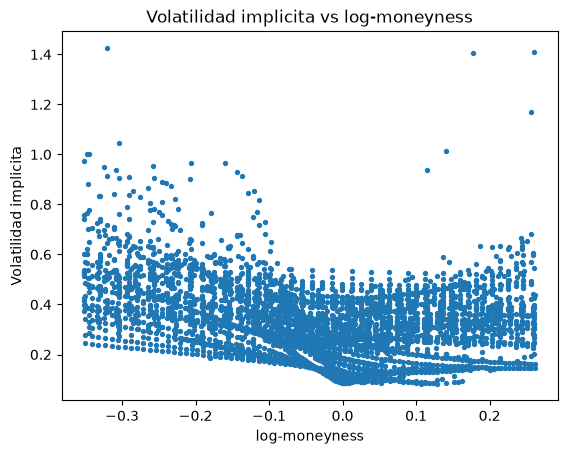

In [7]:
plt.scatter(df['logm'], df['impliedVolatility'], s=8)

plt.xlabel('log-moneyness')
plt.ylabel('Volatilidad implicita')
plt.title('Volatilidad implicita vs log-moneyness')

plt.show()

En la gráfica no se observa una relación completamente lineal. Hay curvatura, por lo que tiene sentido comparar un modelo lineal con modelos polinomiales.

## 5. Pipeline

El proceso que seguimos es:

**Dataset**
→ limpieza  
→ creación de variables  
→ train-test-split  
→ `StandardScaler` para variables numéricas  
→ `OneHotEncoder` para variables cualitativas  
→ `PolynomialFeatures` cuando el modelo lo necesita  
→ regresión  
→ predicción  
→ R2 y análisis de residuos

Se usa la semilla 15 para que la división de los datos pueda repetirse.

In [8]:
X = df[['logm','T','logvol','logoi','ticker','tipo']]
y = df['logIV']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=15
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (3184, 6)
Test: (1062, 6)


In [9]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=15
)

## 6. Modelo 1 — Regresión lineal

El primer modelo es el más sencillo. Usa `logm` y `T` como variables numéricas y también incluye ticker y tipo de opción.

Primero escalamos las variables numéricas y hacemos One Hot Encoding a las cualitativas.

In [10]:
num_m1 = ['logm','T']
cat_m1 = ['ticker','tipo']

pre_m1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_m1),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_m1)
    ]
)

In [11]:
m1_lineal = Pipeline([
    ('preprocessor', pre_m1),
    ('model', LinearRegression())
])

m1_ridge = Pipeline([
    ('preprocessor', pre_m1),
    ('model', Ridge(alpha=1))
])

m1_lasso = Pipeline([
    ('preprocessor', pre_m1),
    ('model', Lasso(alpha=0.001, max_iter=10000))
])

m1_elastic = Pipeline([
    ('preprocessor', pre_m1),
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
])

In [12]:
X1_train = X_train[num_m1 + cat_m1]
X1_test = X_test[num_m1 + cat_m1]

m1_lineal.fit(X1_train, y_train)
m1_ridge.fit(X1_train, y_train)
m1_lasso.fit(X1_train, y_train)
m1_elastic.fit(X1_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['logm','T','ticker','tipo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transf

In [13]:
resultados_m1 = pd.DataFrame({
    'Version':['Sin penalizacion','Ridge','Lasso','ElasticNet'],
    'R2 train':[
        m1_lineal.score(X1_train,y_train),
        m1_ridge.score(X1_train,y_train),
        m1_lasso.score(X1_train,y_train),
        m1_elastic.score(X1_train,y_train)
    ],
    'R2 test':[
        m1_lineal.score(X1_test,y_test),
        m1_ridge.score(X1_test,y_test),
        m1_lasso.score(X1_test,y_test),
        m1_elastic.score(X1_test,y_test)
    ]
})

resultados_m1

,Version,R2 train,R2 test
0,Sin penalizacion,0.662653,0.616871
1,Ridge,0.662651,0.616858
2,Lasso,0.662075,0.615874
3,ElasticNet,0.662465,0.616456


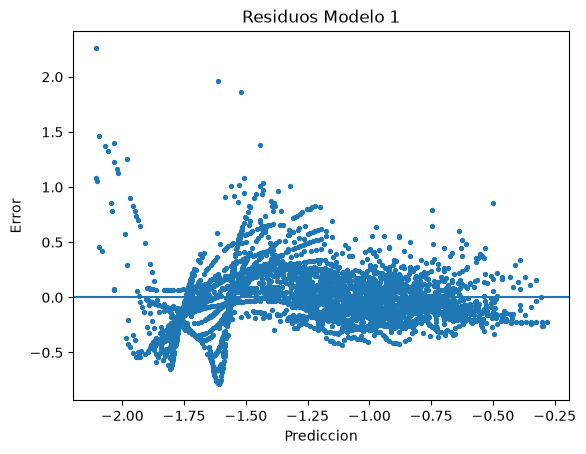

In [14]:
pred_m1 = m1_lineal.predict(X1_train)

error_m1 = y_train - pred_m1

plt.scatter(pred_m1, error_m1, s=8)
plt.axhline(0)

plt.xlabel('Prediccion')
plt.ylabel('Error')
plt.title('Residuos Modelo 1')

plt.show()

### Análisis del Modelo 1

El modelo lineal sirve como punto de comparación, pero los residuos todavía muestran una forma y no parecen completamente aleatorios.

Esto indica que una línea no alcanza a representar toda la relación. Por eso en el segundo modelo agregamos términos polinomiales.

## 7. Modelo 2 — Regresión polinomial grado 3

En este modelo usamos las mismas variables principales, pero `PolynomialFeatures` crea potencias e interacciones entre `logm` y `T`.

Esto permite que el modelo capture la curvatura que vimos en los residuos del modelo anterior.

In [15]:
poly_m2 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False))
])

pre_m2 = ColumnTransformer(
    transformers=[
        ('num', poly_m2, ['logm','T']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['ticker','tipo'])
    ]
)

In [16]:
m2_lineal = Pipeline([
    ('preprocessor', pre_m2),
    ('model', LinearRegression())
])

m2_ridge = Pipeline([
    ('preprocessor', pre_m2),
    ('model', Ridge(alpha=1))
])

m2_lasso = Pipeline([
    ('preprocessor', pre_m2),
    ('model', Lasso(alpha=0.001, max_iter=10000))
])

m2_elastic = Pipeline([
    ('preprocessor', pre_m2),
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
])

In [17]:
X2_train = X_train[['logm','T','ticker','tipo']]
X2_test = X_test[['logm','T','ticker','tipo']]

m2_lineal.fit(X2_train, y_train)
m2_ridge.fit(X2_train, y_train)
m2_lasso.fit(X2_train, y_train)
m2_elastic.fit(X2_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['logm','T','ticker','tipo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transf

In [18]:
resultados_m2 = pd.DataFrame({
    'Version':['Sin penalizacion','Ridge','Lasso','ElasticNet'],
    'R2 train':[
        m2_lineal.score(X2_train,y_train),
        m2_ridge.score(X2_train,y_train),
        m2_lasso.score(X2_train,y_train),
        m2_elastic.score(X2_train,y_train)
    ],
    'R2 test':[
        m2_lineal.score(X2_test,y_test),
        m2_ridge.score(X2_test,y_test),
        m2_lasso.score(X2_test,y_test),
        m2_elastic.score(X2_test,y_test)
    ]
})

resultados_m2

,Version,R2 train,R2 test
0,Sin penalizacion,0.762927,0.746770
1,Ridge,0.762925,0.746746
2,Lasso,0.762227,0.745043
3,ElasticNet,0.762707,0.746007


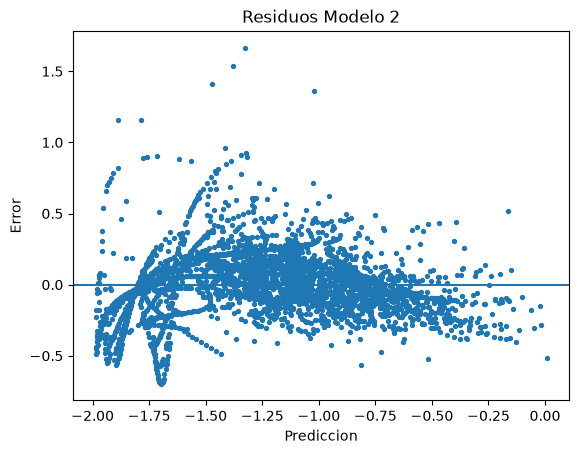

In [19]:
pred_m2 = m2_lineal.predict(X2_train)

error_m2 = y_train - pred_m2

plt.scatter(pred_m2, error_m2, s=8)
plt.axhline(0)

plt.xlabel('Prediccion')
plt.ylabel('Error')
plt.title('Residuos Modelo 2')

plt.show()

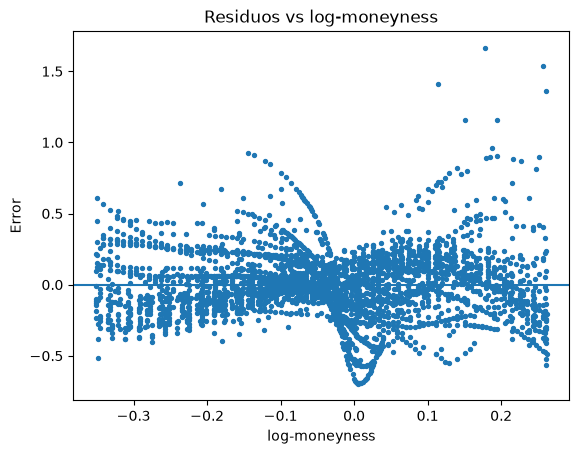

In [20]:
plt.scatter(X2_train['logm'], error_m2, s=8)
plt.axhline(0)

plt.xlabel('log-moneyness')
plt.ylabel('Error')
plt.title('Residuos vs log-moneyness')

plt.show()

### Análisis del Modelo 2

Al agregar el polinomio, el modelo puede seguir mejor la curvatura de los datos.

Si comparamos los residuos con el Modelo 1, la forma debería disminuir. Aun así, la volatilidad también puede depender de qué tan líquido sea el contrato.

Por eso en el tercer modelo agregamos volumen y open interest.

## 8. Modelo 3 — Polinomial grado 3 con liquidez

El tercer modelo conserva el polinomio para `logm` y `T`, y agrega:

- `logvol`
- `logoi`

Estas variables se agregan de manera lineal y estandarizada. Así el modelo sigue siendo entendible y no genera una cantidad demasiado grande de coeficientes.

In [21]:
poly_m3 = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False))
])

pre_m3 = ColumnTransformer(
    transformers=[
        ('poly', poly_m3, ['logm','T']),
        ('liquidez', StandardScaler(), ['logvol','logoi']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['ticker','tipo'])
    ]
)

In [22]:
m3_lineal = Pipeline([
    ('preprocessor', pre_m3),
    ('model', LinearRegression())
])

m3_ridge = Pipeline([
    ('preprocessor', pre_m3),
    ('model', Ridge(alpha=1))
])

m3_lasso = Pipeline([
    ('preprocessor', pre_m3),
    ('model', Lasso(alpha=0.001, max_iter=10000))
])

m3_elastic = Pipeline([
    ('preprocessor', pre_m3),
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
])

In [23]:
X3_train = X_train[['logm','T','logvol','logoi','ticker','tipo']]
X3_test = X_test[['logm','T','logvol','logoi','ticker','tipo']]

m3_lineal.fit(X3_train, y_train)
m3_ridge.fit(X3_train, y_train)
m3_lasso.fit(X3_train, y_train)
m3_elastic.fit(X3_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['logm','T','logvol','logoi','ticker','tipo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('poly', ...), ('liquidez', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated w

In [24]:
resultados_m3 = pd.DataFrame({
    'Version':['Sin penalizacion','Ridge','Lasso','ElasticNet'],
    'R2 train':[
        m3_lineal.score(X3_train,y_train),
        m3_ridge.score(X3_train,y_train),
        m3_lasso.score(X3_train,y_train),
        m3_elastic.score(X3_train,y_train)
    ],
    'R2 test':[
        m3_lineal.score(X3_test,y_test),
        m3_ridge.score(X3_test,y_test),
        m3_lasso.score(X3_test,y_test),
        m3_elastic.score(X3_test,y_test)
    ]
})

resultados_m3

,Version,R2 train,R2 test
0,Sin penalizacion,0.796296,0.785702
1,Ridge,0.796294,0.785650
2,Lasso,0.795708,0.783943
3,ElasticNet,0.796072,0.784765


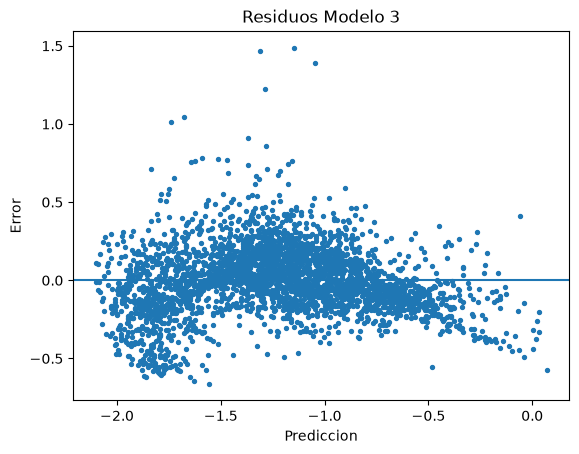

In [25]:
pred_m3 = m3_lineal.predict(X3_train)

error_m3 = y_train - pred_m3

plt.scatter(pred_m3, error_m3, s=8)
plt.axhline(0)

plt.xlabel('Prediccion')
plt.ylabel('Error')
plt.title('Residuos Modelo 3')

plt.show()

### Análisis del Modelo 3

Este modelo agrega información de liquidez sin aumentar demasiado la complejidad.

Si el R2 mejora respecto al Modelo 2, significa que volumen y open interest sí aportan información para explicar la volatilidad implícita.

Las versiones penalizadas sirven para revisar si reducir los coeficientes mejora el desempeño fuera de la muestra.

## 9. Validación cruzada

Además del train-test-split, usamos K-Fold con 5 grupos. Esto nos ayuda a no depender solamente de una división de los datos.

In [26]:
modelos_cv = {
    'M1 Lineal': (m1_lineal, X1_train),
    'M2 Polinomial': (m2_lineal, X2_train),
    'M3 Polinomial + liquidez': (m3_lineal, X3_train)
}

for nombre, (modelo, datos) in modelos_cv.items():
    scores = cross_val_score(
        modelo,
        datos,
        y_train,
        cv=kfold,
        scoring='r2'
    )

    print(nombre)
    print('R2 promedio:', scores.mean())
    print()

M1 Lineal
R2 promedio: 0.6612242465580216

M2 Polinomial
R2 promedio: 0.760261267548653

M3 Polinomial + liquidez
R2 promedio: 0.7933824127509886



## 10. Comparación de los modelos

In [27]:
resultados_m1['Modelo'] = 'Modelo 1'
resultados_m2['Modelo'] = 'Modelo 2'
resultados_m3['Modelo'] = 'Modelo 3'

resultados = pd.concat(
    [resultados_m1, resultados_m2, resultados_m3],
    ignore_index=True
)

resultados[['Modelo','Version','R2 train','R2 test']]

,Modelo,Version,R2 train,R2 test
0,Modelo 1,Sin penalizacion,0.662653,0.616871
1,Modelo 1,Ridge,0.662651,0.616858
2,Modelo 1,Lasso,0.662075,0.615874
3,Modelo 1,ElasticNet,0.662465,0.616456
4,Modelo 2,Sin penalizacion,0.762927,0.746770
5,Modelo 2,Ridge,0.762925,0.746746
6,Modelo 2,Lasso,0.762227,0.745043
7,Modelo 2,ElasticNet,0.762707,0.746007
8,Modelo 3,Sin penalizacion,0.796296,0.785702
9,Modelo 3,Ridge,0.796294,0.785650


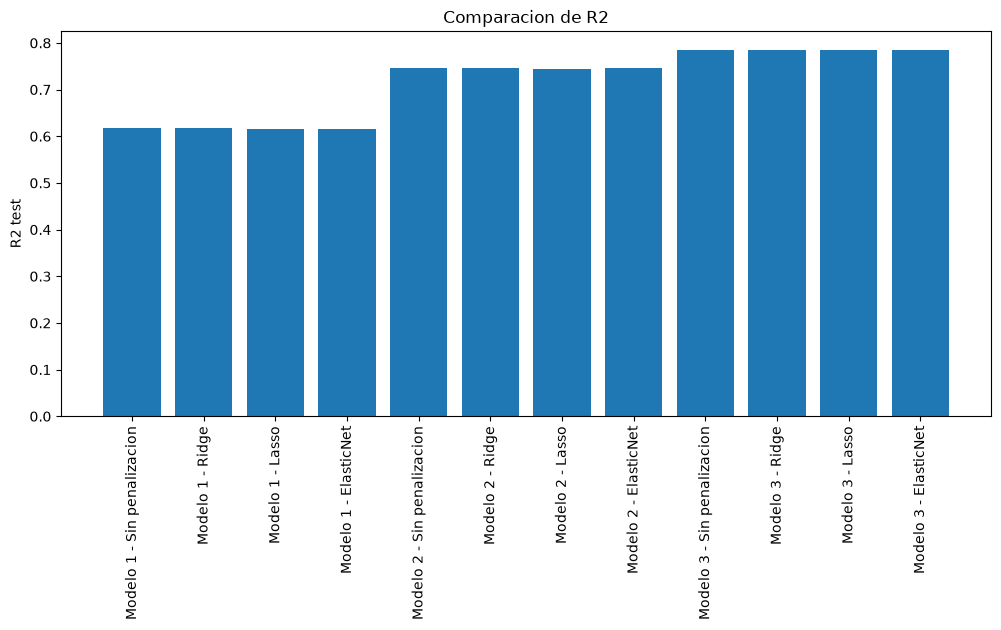

In [28]:
etiquetas = resultados['Modelo'] + ' - ' + resultados['Version']

plt.figure(figsize=(12,5))

plt.bar(etiquetas, resultados['R2 test'])

plt.ylabel('R2 test')
plt.title('Comparacion de R2')
plt.xticks(rotation=90)

plt.show()

### Lectura de la comparación

La comparación debe hacerse principalmente con el R2 de prueba y no solamente con el de entrenamiento.

Si un modelo tiene un R2 muy alto en train pero baja mucho en test, puede estar sobreajustando.

En este caso esperamos que el Modelo 2 mejore al lineal por la curvatura y que el Modelo 3 mejore al incorporar la liquidez. La regularización se compara para ver si ayuda a mantener un desempeño más estable.

## 11. Significancia de factores

La significancia se revisa sobre el Modelo 3 **sin penalización**, porque OLS permite obtener directamente errores estándar, t y p-values.

In [29]:
# Transformamos X con el mismo preprocesamiento del Modelo 3
X3_ols = pre_m3.fit_transform(X3_train)

# Nombres de las variables creadas
nombres = pre_m3.get_feature_names_out()

X3_ols = pd.DataFrame(
    X3_ols,
    columns=nombres,
    index=X3_train.index
)

# Agregamos constante para beta 0
X3_ols = sm.add_constant(X3_ols)

modelo_ols = sm.OLS(y_train, X3_ols)

resultado_ols = modelo_ols.fit()

print(resultado_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  logIV   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     728.0
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:36:20   Log-Likelihood:                 386.35
No. Observations:                3184   AIC:                            -736.7
Df Residuals:                    3166   BIC:                            -627.5
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.1625      0.015  

In [30]:
significancia = pd.DataFrame({
    'Coeficiente': resultado_ols.params,
    'Error estandar': resultado_ols.bse,
    't': resultado_ols.tvalues,
    'P-value': resultado_ols.pvalues
})

significancia.round(4)

,Coeficiente,Error estandar,t,P-value
const,-1.1625,0.0151,-77.1124,0.0000
poly__logm,-0.2812,0.0095,-29.6012,0.0000
poly__T,-0.0379,0.0102,-3.7158,0.0002
poly__logm^2,0.0986,0.0037,26.4320,0.0000
poly__logm T,0.0143,0.0072,1.9876,0.0469
poly__T^2,0.0475,0.0145,3.2837,0.0010
poly__logm^3,0.0533,0.0032,16.4884,0.0000
poly__logm^2 T,-0.0451,0.0033,-13.5193,0.0000
poly__logm T^2,-0.0031,0.0038,-0.8116,0.4171
poly__T^3,-0.0056,0.0063,-0.8919,0.3725


Para interpretar esta tabla usamos:

- p-value < 0.05 → el factor es significativo.
- p-value > 0.05 → no tenemos suficiente evidencia para decir que el factor es significativo.

No significa que un factor con p-value alto sea inútil en todos los casos, solamente que en este modelo no hay evidencia suficiente para separarlo de cero.

## 12. Análisis de los 6 problemas comunes

Usamos el Modelo 3 sin penalización porque es el modelo final que queremos interpretar.

### 12.1 No linealidad

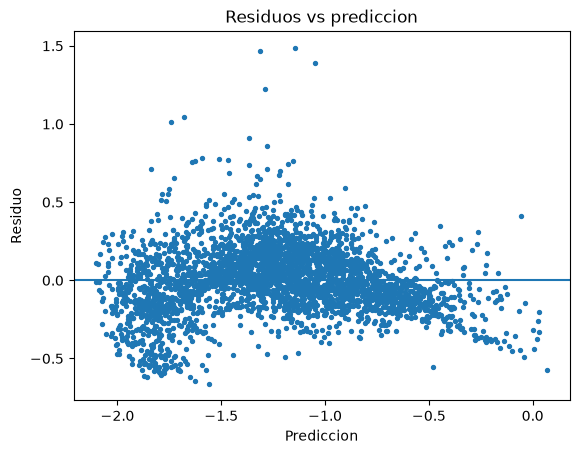

In [31]:
pred_ols = resultado_ols.predict(X3_ols)
residuos = resultado_ols.resid

plt.scatter(pred_ols, residuos, s=8)
plt.axhline(0)

plt.xlabel('Prediccion')
plt.ylabel('Residuo')
plt.title('Residuos vs prediccion')

plt.show()

In [32]:
reset = linear_reset(resultado_ols, power=2, use_f=True)

print('P-value RESET:', reset.pvalue)

P-value RESET: 4.390107361009481e-171


Si el p-value de RESET es menor a 0.05, todavía hay evidencia de que falta alguna relación no lineal en el modelo.

### 12.2 Correlación de errores

In [33]:
DW = durbin_watson(residuos)

print('Durbin-Watson:', DW)

Durbin-Watson: 1.9687340472980404


Un valor cercano a 2 indica que no se observa una correlación importante entre los errores.

### 12.3 Colinealidad

In [34]:
VIF = pd.DataFrame()

VIF['Variable'] = X3_ols.columns
VIF['VIF'] = [
    variance_inflation_factor(X3_ols.values, i)
    for i in range(X3_ols.shape[1])
]

VIF[VIF['Variable'] != 'const'].sort_values('VIF', ascending=False)

,Variable,VIF
9,poly__T^3,54.626188
5,poly__T^2,42.104044
2,poly__T,7.176841
1,poly__logm,6.218318
8,poly__logm T^2,5.489003
6,poly__logm^3,5.163725
4,poly__logm T,4.338834
15,cat__ticker_SPY,3.039084
10,liquidez__logvol,2.622594
11,liquidez__logoi,2.317743


Valores VIF altos indican que algunas variables están muy relacionadas entre sí. En modelos polinomiales esto puede aparecer porque una variable y sus potencias están relacionadas.

### 12.4 Outliers

In [35]:
influencia = resultado_ols.get_influence()

residuos_student = influencia.resid_studentized_external

outliers = np.where(np.abs(residuos_student) > 3)[0]

print('Numero de outliers:', len(outliers))

Numero de outliers: 25


Se consideran observaciones importantes las que tienen un residuo studentizado mayor a 3 en valor absoluto.

### 12.5 High leverage points

In [36]:
leverage = influencia.hat_matrix_diag

n = X3_ols.shape[0]
p = X3_ols.shape[1]

limite = 2*p/n

HL = np.where(leverage > limite)[0]

print('Limite:', limite)
print('High leverage points:', len(HL))

Limite: 0.011306532663316583
High leverage points: 173


Los high leverage points son observaciones que tienen valores poco comunes en las variables independientes.

### 12.6 Heterocedasticidad

In [37]:
BP = het_breuschpagan(
    residuos,
    resultado_ols.model.exog
)

print('P-value Breusch-Pagan:', BP[1])

P-value Breusch-Pagan: 2.907258407913126e-102


Si el p-value es menor a 0.05, existe evidencia de heterocedasticidad, es decir, la variación de los errores no es constante.

## 13. Conclusión

El objetivo del trabajo fue construir y comparar diferentes modelos para explicar la volatilidad implícita.

El primer modelo sirve como una base, pero al revisar sus residuos se observa que una relación solamente lineal no representa completamente los datos. Por esta razón se agregó una regresión polinomial en el segundo modelo.

El tercer modelo agrega variables de liquidez. Esto permite revisar si el volumen y el open interest contienen información adicional para explicar la volatilidad.

La comparación debe hacerse con los R2 de prueba y de validación cruzada. El modelo que tenga el mejor resultado fuera de muestra es el que consideramos más útil, no necesariamente el que tenga el R2 de entrenamiento más alto.

Las penalizaciones Ridge, Lasso y ElasticNet permiten comparar si reducir el tamaño de los coeficientes ayuda a controlar la complejidad del modelo.

Finalmente, el análisis OLS y de residuos permite identificar qué factores son significativos y cuáles de los seis problemas siguen presentes. Esto muestra que no basta con obtener un R2 alto; también es necesario revisar si el comportamiento de los residuos es razonable para poder interpretar mejor el modelo.

## 14. Referencias

Breusch, T. S., & Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica, 47*(5), 1287–1294.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.

scikit-learn developers. (2026). *scikit-learn documentation*.

statsmodels developers. (2026). *statsmodels documentation*.

Yahoo Finance. (2026). *Options market data*.
